In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
df = pd.read_csv("used_cars_dataset.csv")
print(df.info())
print(f"\n Describe: {df.describe()} and Samples =5 {df.sample(5)}")

<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   car_id              4500 non-null   int64  
 1   make                4500 non-null   str    
 2   model               4500 non-null   str    
 3   year                4500 non-null   int64  
 4   mileage             4500 non-null   int64  
 5   price               4500 non-null   float64
 6   transmission        4500 non-null   str    
 7   fuel_type           4500 non-null   str    
 8   condition           4410 non-null   str    
 9   seller_rating       4320 non-null   float64
 10  num_photos          4500 non-null   int64  
 11  description_length  4500 non-null   int64  
 12  days_listed         4500 non-null   int64  
 13  sold_fast           4500 non-null   int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 619.6 KB
None



 Describe:             car_id         year        mileage         price  seller_rating  \
count  4500.000000  4500.000000    4500.000000   4500.000000    4320.000000   
mean   3250.500000  2014.166667   71898.678222   6328.079942       4.172824   
std    1299.182435     5.485397   48837.052450   6227.915551       0.552958   
min    1001.000000  2005.000000    5990.000000   1500.000000       2.000000   
25%    2125.750000  2009.000000   39399.750000   1500.000000       3.800000   
50%    3250.500000  2014.000000   59104.500000   3563.185000       4.200000   
75%    4375.250000  2019.000000   90292.000000   9745.310000       4.600000   
max    5500.000000  2023.000000  497540.000000  34425.340000       5.000000   

        num_photos  description_length  days_listed    sold_fast  
count  4500.000000         4500.000000  4500.000000  4500.000000  
mean     18.702444          398.556889    59.553778     0.453333  
std       9.288498          150.282897    34.338029     0.497873  
min     

In [3]:
print(f"Number of Empty Values in the Dataset: {df.isnull().sum()}")
#print(f"Number of Duplicated Values in the Dataset: {df.duplicated().sum()}")

print(f" Number of Rows in Dataset: {df.shape[0]} and Number of Columns in Dataset: {df.shape[1]} with Columns = {df.columns}and Data Types = {df.dtypes}")

Number of Empty Values in the Dataset: car_id                  0
make                    0
model                   0
year                    0
mileage                 0
price                   0
transmission            0
fuel_type               0
condition              90
seller_rating         180
num_photos              0
description_length      0
days_listed             0
sold_fast               0
dtype: int64
 Number of Rows in Dataset: 4500 and Number of Columns in Dataset: 14 with Columns = Index(['car_id', 'make', 'model', 'year', 'mileage', 'price', 'transmission',
       'fuel_type', 'condition', 'seller_rating', 'num_photos',
       'description_length', 'days_listed', 'sold_fast'],
      dtype='str')and Data Types = car_id                  int64
make                      str
model                     str
year                    int64
mileage                 int64
price                 float64
transmission              str
fuel_type                 str
condition               

In [4]:
# Let's drop the columns we don't need.
# 'car_id' is just an identifier (like a license plate), it doesn't help predict if a car sells.
# 'days_listed' is something we only know AFTER the car sells, so we can't use it to predict the future.
# axis=1 tells pandas we want to drop COLUMNS, not rows.
# inplace=True tells pandas to modify our current dataframe directly.
df.drop(['car_id', 'days_listed'], axis=1, inplace=True)

In [5]:
df.dtypes

make                      str
model                     str
year                    int64
mileage                 int64
price                 float64
transmission              str
fuel_type                 str
condition                 str
seller_rating         float64
num_photos              int64
description_length      int64
sold_fast               int64
dtype: object

# --- Dropping Missing Values ---
# Instead of filling them, we will drop any row that has a missing value.
# The 'dropna()' function looks for missing values. 
# inplace=True applies the change directly to our dataframe.


In [7]:
print(f"Rows before dropping missing data: {len(df)}")

df.dropna(inplace=True)

print(f"Rows after dropping missing data: {len(df)}")
# We check for missing values again. If everything worked, the output should show all 0s!
print("\n--- Missing values after cleaning: ---")
print(df.isnull().sum())

Rows before dropping missing data: 4234
Rows after dropping missing data: 4234

--- Missing values after cleaning: ---
make                  0
model                 0
year                  0
mileage               0
price                 0
transmission          0
fuel_type             0
condition             0
seller_rating         0
num_photos            0
description_length    0
sold_fast             0
dtype: int64


# X contains everything EXCEPT 'sold_fast'. We use axis=1 to drop the column.
# y contains ONLY 'sold_fast'. This is what we want to predict.

In [8]:

X = df.drop('sold_fast', axis=1)

y = df['sold_fast']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")


Training data size: 3175 rows
Testing data size: 1059 rows


# Encode Text/Categorical Columns into Numbers
# pd.get_dummies automatically finds text columns and turns them into 1s and 0s.
# drop_first=True is a trick we use for Logistic Regression to avoid redundant columns.

In [11]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

In [12]:

# IMPORTANT: Sometimes the training set has categories the test set doesn't, or vice versa.
# This line makes sure the columns match perfectly in both sets.
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [16]:
# Scale the Numbers
# StandardScaler makes all numbers have a mean of 0 and a standard deviation of 1.
scaler = StandardScaler()
# We "fit" the scaler ONLY on the training data. 
# Why? Because the model shouldn't know anything about the test data's averages yet!
X_train_scaled = scaler.fit_transform(X_train_encoded)

# We only "transform" the test data using the rules learned from the training data.
X_test_scaled = scaler.transform(X_test_encoded)

print("\nData is now encoded and scaled! Ready for Machine Learning.")
print(f"Total features after encoding: {X_train_scaled.shape[1]}")



Data is now encoded and scaled! Ready for Machine Learning.
Total features after encoding: 26


In [17]:

# We import our two algorithms from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# For KNN, we set n_neighbors=5. This means the model will look at the 7 closest cars to make a decision. We will check for optimal Values later.
log_model = LogisticRegression(C=0.1,max_iter=1000) # max_iter=1000 gives the model more time to learn if the data is complex and Regularization parameter C=0.1 to prevent overfitting
knn_model = KNeighborsClassifier(n_neighbors=7)

print("Training Logistic Regression...")
# .fit() is where the actual "learning" happens. We feed it our scaled training data and the answers (y_train).
log_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained successfully!\n")

print("Training K-Nearest Neighbors...")
# We do the same for KNN.
knn_model.fit(X_train_scaled, y_train)
print("KNN trained successfully!\n")

# Now that they have learned, let's ask them to make predictions on our Test data.
# We give them X_test_scaled (the features they haven't seen yet) and ask them to guess if they sold fast.
log_predictions = log_model.predict(X_test_scaled)
knn_predictions = knn_model.predict(X_test_scaled)

print("Predictions made by both models!")

Training Logistic Regression...
Logistic Regression trained successfully!

Training K-Nearest Neighbors...
KNN trained successfully!

Predictions made by both models!


#Let's Try to get the Best Results by finding Optimal C and max_iter for Logistic Regression and n_neighbors for KNN model

--- Logistic Regression Tuning ---
Best parameters: {'C': 1, 'max_iter': 250}
Best cross-validation score: 0.6995



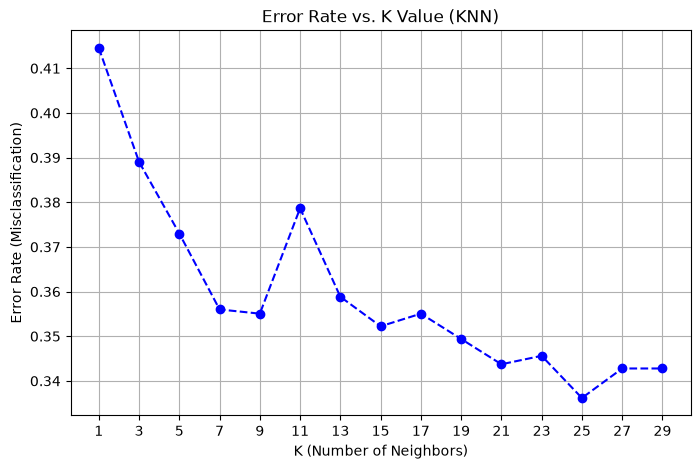


--- KNN Tuning ---
Best K value based on lowest error: 25


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# TUNING LOGISTIC REGRESSION
# ==========================================
# We don't need a pipeline because X_train_scaled is ALREADY scaled!
log_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [250, 500, 1000, 2000] 
}

log_grid = GridSearchCV(LogisticRegression(), log_param_grid, cv=5, scoring='accuracy')
log_grid.fit(X_train_scaled, y_train)

print("--- Logistic Regression Tuning ---")
print(f"Best parameters: {log_grid.best_params_}")
print(f"Best cross-validation score: {log_grid.best_score_:.4f}\n")

# ==========================================
# TUNING KNN (Elbow Method)
# ==========================================
k_values = list(range(1, 31, 2)) # Testing K = 1, 3, 5... up to 29
error_rate = []

# We use X_train_scaled and X_test_scaled here!
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    
    # Calculate the error rate (1 - accuracy)
    error_rate.append(np.mean(pred_k != y_test))

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, error_rate, marker='o', linestyle='dashed', color='b')
plt.title('Error Rate vs. K Value (KNN)')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate (Misclassification)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find the best K
best_k = k_values[error_rate.index(min(error_rate))]
print(f"\n--- KNN Tuning ---")
print(f"Best K value based on lowest error: {best_k}")

In [ ]:
# ==========================================
#  FINAL EVALUATION WITH BEST PARAMETERS
# ==========================================

# 1. Initialize the models with YOUR BEST PARAMETERS!
best_log_model = LogisticRegression(C=1, max_iter=250)
best_knn_model = KNeighborsClassifier(n_neighbors=25)

# 2. Train them on the scaled training data
best_log_model.fit(X_train_scaled, y_train)
best_knn_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the unseen test data
log_pred = best_log_model.predict(X_test_scaled)
knn_pred = best_knn_model.predict(X_test_scaled)

# 4. Evaluate Logistic Regression
print("--- LOGISTIC REGRESSION RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, log_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, log_pred))

# 5. Evaluate KNN
print("\n--- KNN RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, knn_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, knn_pred))

--- LOGISTIC REGRESSION RESULTS ---
Accuracy: 0.6988
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       573
           1       0.68      0.64      0.66       486

    accuracy                           0.70      1059
   macro avg       0.70      0.69      0.70      1059
weighted avg       0.70      0.70      0.70      1059


--- KNN RESULTS ---
Accuracy: 0.6638
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.70      0.69       573
           1       0.64      0.62      0.63       486

    accuracy                           0.66      1059
   macro avg       0.66      0.66      0.66      1059
weighted avg       0.66      0.66      0.66      1059



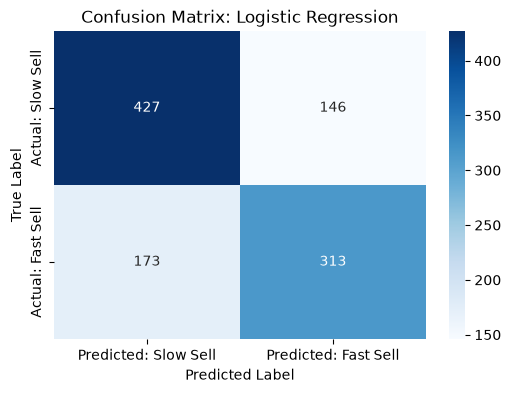

--- Confusion Matrix Breakdown ---
True Negatives  (Correctly predicted SLOW sell): 427
False Positives (Predicted FAST, but was actually SLOW): 146
False Negatives (Predicted SLOW, but was actually FAST): 173
True Positives  (Correctly predicted FAST sell): 313


In [20]:
# ==========================================
# STEP 6: VISUALIZING THE CONFUSION MATRIX
# ==========================================

# We will use our winning model: best_log_model
# We already have its predictions in 'log_pred'

# 1. Calculate the confusion matrix
cm = confusion_matrix(y_test, log_pred)

# 2. Set up the plot
plt.figure(figsize=(6, 4))

# 3. Draw the heatmap
# annot=True puts the numbers inside the squares
# fmt='d' makes sure the numbers are whole numbers, not decimals
# cmap='Blues' makes it look nice and professional
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Slow Sell', 'Predicted: Fast Sell'],
            yticklabels=['Actual: Slow Sell', 'Actual: Fast Sell'])

plt.title('Confusion Matrix: Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Let's also print the numbers in plain English so they are impossible to misunderstand
tn, fp, fn, tp = cm.ravel()
print("--- Confusion Matrix Breakdown ---")
print(f"True Negatives  (Correctly predicted SLOW sell): {tn}")
print(f"False Positives (Predicted FAST, but was actually SLOW): {fp}")
print(f"False Negatives (Predicted SLOW, but was actually FAST): {fn}")
print(f"True Positives  (Correctly predicted FAST sell): {tp}")

In [22]:
# ==========================================
# STEP 7: SAVING THE MODEL TO A PICKLE FILE
# ==========================================
import pickle

# We will save our winning Logistic Regression model.
# We name the file 'used_car_logreg_model.pkl'
filename = 'used_car_logreg_model.pkl'

# Open the file in 'write-binary' ('wb') mode and dump the model into it
with open(filename, 'wb') as file:
    pickle.dump(best_log_model, file)

print(f"Model successfully saved to {filename}!")

Model successfully saved to used_car_logreg_model.pkl!


In [23]:
# --- HOW TO LOAD THE MODEL LATER ---

# Open the file in 'read-binary' ('rb') mode
with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")
# Now 'loaded_model' acts exactly like 'best_log_model' did, 
# but you didn't have to run any training code!

Model loaded successfully!


/var/folders/ks/sp26_25d5qx2pl5vw8yx56km0000gn/T/ipykernel_34615/3027100098.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight (Importance)', y='Feature', data=importance_df.head(15), palette='coolwarm')


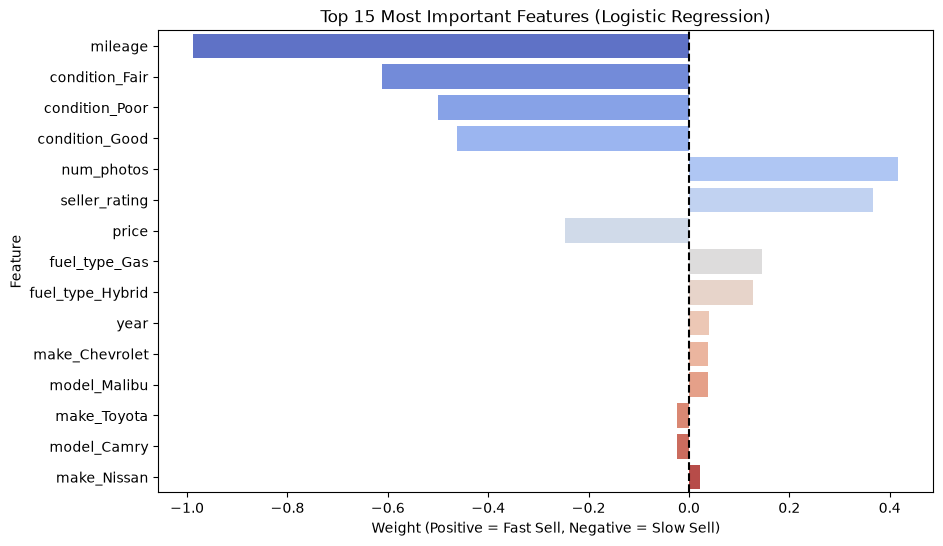

--- Top 5 Drivers of a FAST Sale (Positive): ---
             Feature  Weight (Importance)
4         num_photos             0.416408
3      seller_rating             0.366374
21     fuel_type_Gas             0.146395
22  fuel_type_Hybrid             0.127625
0               year             0.039542

--- Top 5 Drivers of a SLOW Sale (Negative): ---
           Feature  Weight (Importance)
1          mileage            -0.987383
23  condition_Fair            -0.612508
25  condition_Poor            -0.500563
24  condition_Good            -0.461963
2            price            -0.247383


In [24]:
# ==========================================
# STEP 8: FEATURE IMPORTANCE (LOGISTIC REGRESSION)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the coefficients (weights) from our trained model
# best_log_model.coef_ gives us an array of numbers. We take the first row [0].
weights = best_log_model.coef_[0]

# 2. Get the names of our columns from the encoded training data
feature_names = X_train_encoded.columns

# 3. Create a nice DataFrame to hold the feature names and their weights together
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight (Importance)': weights
})

# 4. Sort the DataFrame by absolute weight (so the most important features are at the top, regardless of positive/negative)
# We use np.abs() to get the absolute value for sorting purposes only
importance_df['Abs_Weight'] = np.abs(importance_df['Weight (Importance)'])
importance_df = importance_df.sort_values(by='Abs_Weight', ascending=False).drop('Abs_Weight', axis=1)

# 5. Plot the top 15 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Weight (Importance)', y='Feature', data=importance_df.head(15), palette='coolwarm')

plt.title('Top 15 Most Important Features (Logistic Regression)')
plt.xlabel('Weight (Positive = Fast Sell, Negative = Slow Sell)')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--') # Draws a line in the middle
plt.show()

# Let's also print the top 5 in plain text
print("--- Top 5 Drivers of a FAST Sale (Positive): ---")
print(importance_df.sort_values(by='Weight (Importance)', ascending=False).head(5))
print("\n--- Top 5 Drivers of a SLOW Sale (Negative): ---")
print(importance_df.sort_values(by='Weight (Importance)', ascending=True).head(5))